In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [12]:
X_raw = pd.read_csv("data/X_train.csv")
y_train_df = pd.read_csv("data/y_train.csv")

num_cols = X_raw.select_dtypes(include=[np.number]).columns
agg = X_raw.groupby("series_id")[num_cols].agg(["mean", "std"]) 
agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]
X_train = agg.reset_index()
y = y_train_df["surface"]

merged = X_train.merge(y_train_df[["series_id"]].assign(target=y.values), on="series_id", how="inner")
y = merged["target"]
X_train = merged.drop(columns=["target"])

print("X shape:", X_train.shape)
print("y shape:", y.shape)
print("Class counts:\n", y.value_counts())

X shape: (3810, 25)
y shape: (3810,)
Class counts:
 target
concrete                  779
soft_pvc                  732
wood                      607
tiled                     514
fine_concrete             363
hard_tiles_large_space    308
soft_tiles                297
carpet                    189
hard_tiles                 21
Name: count, dtype: int64


In [8]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y, test_size=0.2, random_state=42, stratify=y
)

depth_grid = [5, 10, 15, 20]
results = []

for depth in depth_grid:
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=depth,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    f1 = f1_score(y_val, preds, average="macro")
    results.append((depth, f1))

results_df = pd.DataFrame(results, columns=["max_depth", "f1_macro"])
results_df.sort_values("f1_macro", ascending=False)

,max_depth,f1_macro
3,20,0.920424
2,15,0.919726
1,10,0.860483
0,5,0.571677


In [9]:
best_depth = int(results_df.sort_values("f1_macro", ascending=False).iloc[0]["max_depth"])
print("Best max_depth:", best_depth)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=best_depth,
    random_state=42,
    n_jobs=-1,
    class_weight=None,
)
model.fit(X_tr, y_tr)
preds = model.predict(X_val)

acc = accuracy_score(y_val, preds)
prec = precision_score(y_val, preds, average="macro", zero_division=0)
rec = recall_score(y_val, preds, average="macro", zero_division=0)
f1 = f1_score(y_val, preds, average="macro", zero_division=0)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-macro:  {f1:.4f}")

Best max_depth: 20
Accuracy:  0.9108
Precision: 0.9256
Recall:    0.9158
F1-macro:  0.9204


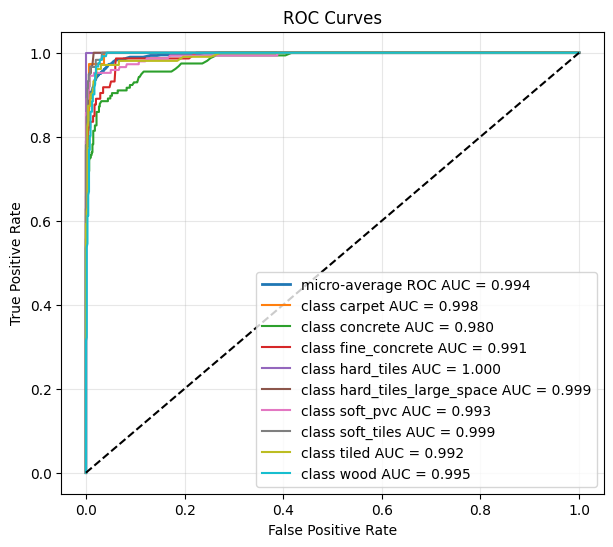

In [10]:
proba = model.predict_proba(X_val)
classes = model.classes_

y_bin = label_binarize(y_val, classes=classes)
fpr = {}
tpr = {}
roc_auc = {}

for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(7, 6))
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f"micro-average ROC AUC = {roc_auc['micro']:.3f}",
    linewidth=2,
)
for i, cls in enumerate(classes):
    plt.plot(fpr[i], tpr[i], label=f"class {cls} AUC = {roc_auc[i]:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()